# Mixed-All Multimodal Dataset Construction

Creates `mm_*_mixed_all_group_test.csv` — a multimodal dataset that uses
**every image exactly once**, with pairing percentages controlling the
combo type and label distribution.

### Design principle
Each image is used once. The number of rows in each split equals the
number of images available in that split.

| Split | Rows = ? |
|---|---|
| Train | number of images in image_train_group_test.csv |
| Val | number of images in image_val_group_test.csv |
| Test | number of images in image_test_group_test.csv |

### Pairing rule
| Image type | Transaction | Combo | Label |
|---|---|---|---|
| 75% bona fide | non-fraud | tab0_img0 | 0 |
| 25% bona fide | fraud | tab1_img0 | 1 |
| 50% forged | non-fraud | tab0_img1 | 1 |
| 50% forged | fraud | tab1_img1 | 1 |

### Source imbalance
MIDV (genuine-only, ~2800 images) will dominate the genuine image combos.
This is **not fixed in the dataset** — it is addressed during training
via WeightedRandomSampler in notebooks 15 and 16.

## 0 · Imports & paths

In [1]:
import sys, os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "notebook" / "results" / "mm_mixed_all_construction"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}

FILES = [
    "mm_train_mixed_all_group_test.csv",
    "mm_val_mixed_all_group_test.csv",
    "mm_test_mixed_all_group_test.csv",
    "mm_full_mixed_all_group_test.csv",
]

print("Data dir:", DATA_DIR)

Data dir: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed


## 1 · Delete old files (run to force rebuild)

In [2]:
for f in FILES:
    path = DATA_DIR / f
    if path.exists():
        os.remove(path)
        print(f"Deleted: {f}")
    else:
        print(f"Not found (ok): {f}")

Not found (ok): mm_train_mixed_all_group_test.csv
Not found (ok): mm_val_mixed_all_group_test.csv
Not found (ok): mm_test_mixed_all_group_test.csv
Not found (ok): mm_full_mixed_all_group_test.csv


## 2 · Build the dataset

In [3]:
script_path = PROJECT_ROOT / "src" / "build_merged_dataset_mixed_all.py"
print("Script exists:", script_path.exists())

all_exist = all((DATA_DIR / f).exists() for f in FILES)

if all_exist:
    print("Files already exist — skipping. Run cell 1 to rebuild.")
elif not script_path.exists():
    print("ERROR: script not found. Copy build_merged_dataset_mixed_all.py to src/ first.")
else:
    print("Building...")
    import subprocess
    result = subprocess.run(
        [sys.executable, str(script_path)],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT)
    )
    print(result.stdout[-5000:] if result.stdout else "(no output)")
    if result.returncode != 0:
        print("\nERRORS:")
        print(result.stderr[-2000:])
    else:
        print("Build complete.")

Script exists: True
Building...
build_merged_dataset_mixed_all.py started
Main block running
Pairing percentages:
  Genuine: 75% non-fraud (tab0_img0) + 25% fraud (tab1_img0)
  Forged:  50% non-fraud (tab0_img1) + 50% fraud (tab1_img1)
Loaded tabular: (6362620, 15)
final_label
0    6354407
1       8213
Name: count, dtype: int64
Loaded image splits: (10164, 11)
final_label
1    5231
0    4933
Name: count, dtype: int64

  train image pools:
    genuine: 3451  →  tab0_img0=2588  tab1_img0=863
    forged:  3731   →  tab0_img1=1866  tab1_img1=1865
  Output rows: 7182  (images in: 7182)

  val image pools:
    genuine: 743  →  tab0_img0=557  tab1_img0=186
    forged:  765   →  tab0_img1=382  tab1_img1=383
  Output rows: 1508  (images in: 1508)

  test image pools:
    genuine: 739  →  tab0_img0=554  tab1_img0=185
    forged:  735   →  tab0_img1=368  tab1_img1=367
  Output rows: 1474  (images in: 1474)
Saved: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\mm_tr

## 3 · Load & verify row counts
Row counts should match the original image split sizes.

In [4]:
train_df = pd.read_csv(DATA_DIR / "mm_train_mixed_all_group_test.csv")
val_df   = pd.read_csv(DATA_DIR / "mm_val_mixed_all_group_test.csv")
test_df  = pd.read_csv(DATA_DIR / "mm_test_mixed_all_group_test.csv")

# Compare with original image split sizes
img_train = pd.read_csv(DATA_DIR / "image_train_group_test.csv")
img_val   = pd.read_csv(DATA_DIR / "image_val_group_test.csv")
img_test  = pd.read_csv(DATA_DIR / "image_test_group_test.csv")

print("Row count comparison:")
print(f"  Train: mm={len(train_df):,}  image={len(img_train):,}  match={len(train_df)==len(img_train)}")
print(f"  Val:   mm={len(val_df):,}   image={len(img_val):,}   match={len(val_df)==len(img_val)}")
print(f"  Test:  mm={len(test_df):,}  image={len(img_test):,}  match={len(test_df)==len(img_test)}")
print(f"\nColumns ({len(train_df.columns)}): {train_df.columns.tolist()}")

Row count comparison:
  Train: mm=7,182  image=7,182  match=True
  Val:   mm=1,508   image=1,508   match=True
  Test:  mm=1,474  image=1,474  match=True

Columns (32): ['tab_step', 'tab_type', 'tab_amount', 'tab_nameOrig', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_nameDest', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFraud', 'tab_isFlaggedFraud', 'tab_sample_id', 'tab_split', 'tab_tabular_id', 'tab_final_label', 'img_image_path', 'img_source_dataset', 'img_image_class', 'img_group_key', 'img_doc_type', 'img_source_type', 'img_file_name', 'img_split_source', 'img_original_label', 'img_split', 'img_final_label', 'final_label', 'tab_fraud_label', 'img_fraud_label', 'combo_type', 'split', 'mm_id']


## 4 · Combo type distribution

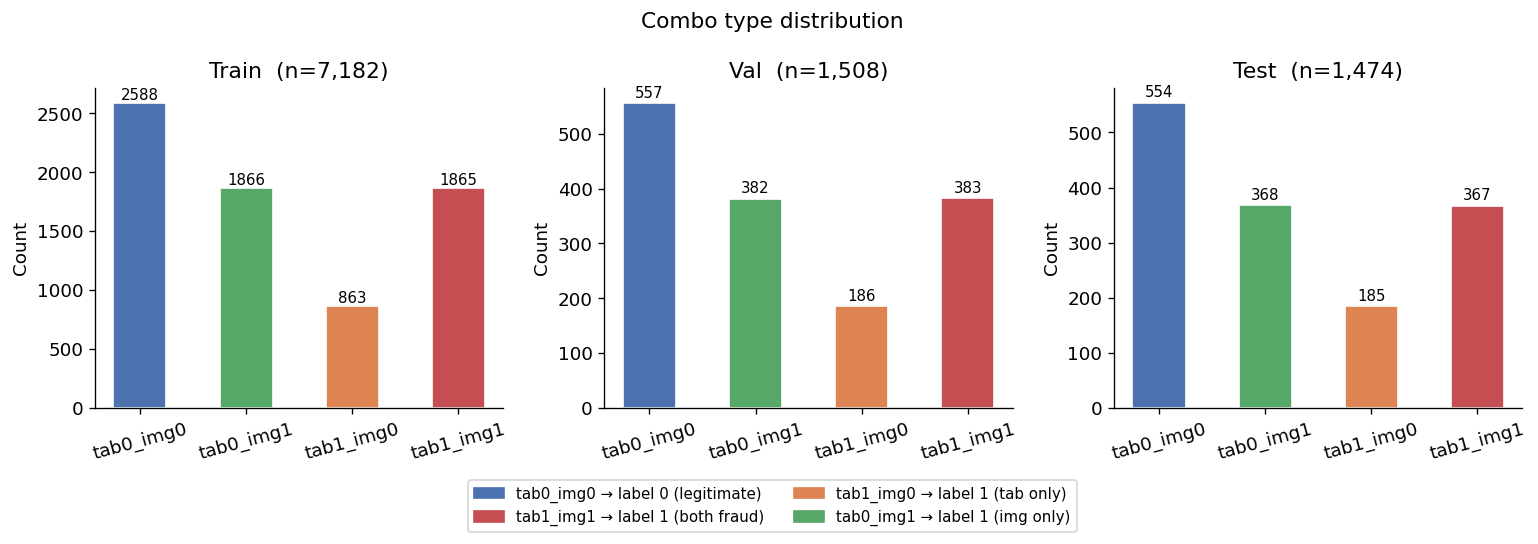

Train combo breakdown:


final_label,0,1,All
combo_type,,,
tab0_img0,2588,0,2588
tab0_img1,0,1866,1866
tab1_img0,0,863,863
tab1_img1,0,1865,1865
All,2588,4594,7182


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, df) in zip(axes, [("Train", train_df),
                                   ("Val",   val_df),
                                   ("Test",  test_df)]):
    combo_counts = df["combo_type"].value_counts().sort_index()
    colours_list = [COMBO_COLOURS.get(c,"gray") for c in combo_counts.index]
    bars = ax.bar(combo_counts.index, combo_counts.values,
                  color=colours_list, edgecolor="white", width=0.5)
    for bar, val in zip(bars, combo_counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(val), ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{name}  (n={len(df):,})")
    ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)

legend_elements = [
    Patch(color="#4C72B0", label="tab0_img0 → label 0 (legitimate)"),
    Patch(color="#C44E52", label="tab1_img1 → label 1 (both fraud)"),
    Patch(color="#DD8452", label="tab1_img0 → label 1 (tab only)"),
    Patch(color="#55A868", label="tab0_img1 → label 1 (img only)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5,-0.12), fontsize=9)
fig.suptitle("Combo type distribution", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "combo_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Train combo breakdown:")
display(pd.crosstab(train_df["combo_type"], train_df["final_label"], margins=True))

## 5 · Label distribution

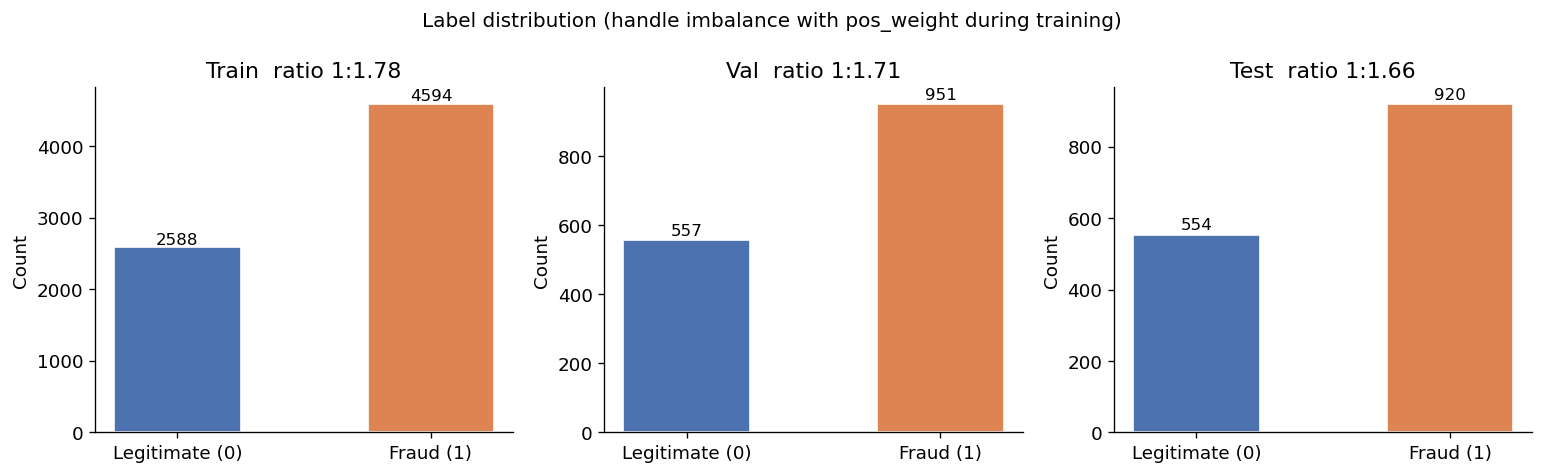

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, df) in zip(axes, [("Train", train_df),
                                   ("Val",   val_df),
                                   ("Test",  test_df)]):
    counts = df["final_label"].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0) / max(counts.get(0,1),1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}")
    ax.set_ylabel("Count"); ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Label distribution (handle imbalance with pos_weight during training)",
             fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Source distribution per combo type
MIDV will dominate genuine combos (tab0_img0, tab1_img0).
This is expected and will be addressed during training with WeightedRandomSampler.

Source x combo_type (train):


combo_type,tab0_img0,tab0_img1,tab1_img0,tab1_img1,All
img_source_dataset,,,,,
fantasyid,484,858,179,833,2354
fmidv,0,1008,0,1032,2040
midv,2104,0,684,0,2788
All,2588,1866,863,1865,7182


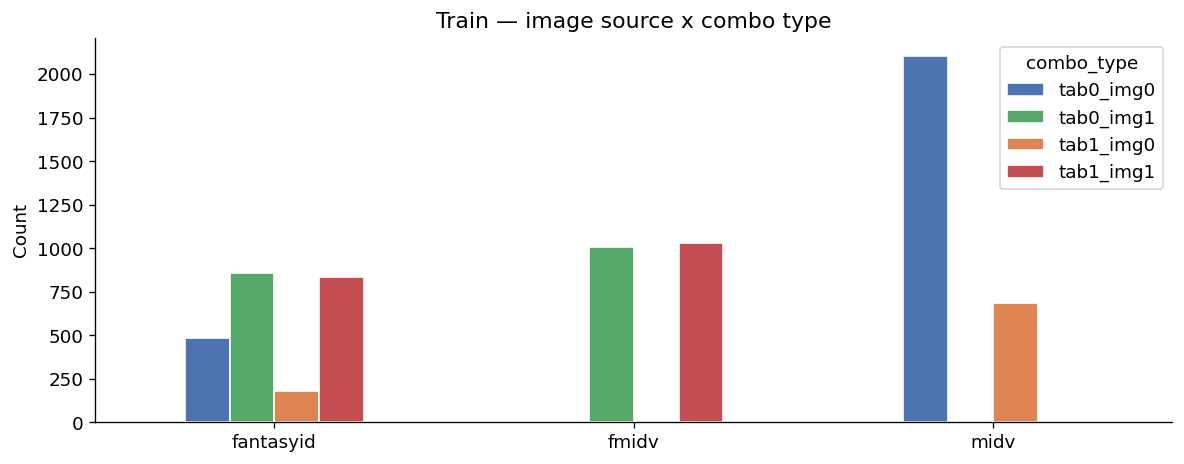

In [7]:
if "img_source_dataset" in train_df.columns:
    print("Source x combo_type (train):")
    display(pd.crosstab(train_df["img_source_dataset"],
                        train_df["combo_type"], margins=True))

    fig, ax = plt.subplots(figsize=(10, 4))
    pd.crosstab(train_df["img_source_dataset"],
                train_df["combo_type"]).plot(
        kind="bar", ax=ax,
        color=[COMBO_COLOURS.get(c,"gray") for c in
               sorted(train_df["combo_type"].unique())],
        edgecolor="white")
    ax.set_title("Train — image source x combo type")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
    ax.set_ylabel("Count"); ax.legend(title="combo_type")
    ax.spines[["top","right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "source_x_combo.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7 · Leakage checks

In [8]:
train_imgs = set(train_df["img_image_path"].dropna())
val_imgs   = set(val_df["img_image_path"].dropna())
test_imgs  = set(test_df["img_image_path"].dropna())

tv = len(train_imgs & val_imgs)
tt = len(train_imgs & test_imgs)
vt = len(val_imgs   & test_imgs)

print("Image path overlap:")
print(f"  Train ∩ Val:  {tv}  {'⚠️  LEAKAGE' if tv>0 else '✅  clean'}")
print(f"  Train ∩ Test: {tt}  {'⚠️  LEAKAGE' if tt>0 else '✅  clean'}")
print(f"  Val   ∩ Test: {vt}  {'⚠️  LEAKAGE' if vt>0 else '✅  clean'}")

# Group key overlap
if "img_group_key" in train_df.columns:
    tg = set(train_df["img_group_key"])
    vg = set(val_df["img_group_key"])
    eg = set(test_df["img_group_key"])
    print(f"\nGroup key overlap:")
    print(f"  Train ∩ Val:  {len(tg & vg)}  {'⚠️' if len(tg & vg)>0 else '✅'}")
    print(f"  Train ∩ Test: {len(tg & eg)}  {'⚠️' if len(tg & eg)>0 else '✅'}")
    print(f"  Val   ∩ Test: {len(vg & eg)}  {'⚠️' if len(vg & eg)>0 else '✅'}")

print(f"\nDuplicate mm_ids:")
print(f"  train: {train_df['mm_id'].duplicated().sum()}")
print(f"  val:   {val_df['mm_id'].duplicated().sum()}")
print(f"  test:  {test_df['mm_id'].duplicated().sum()}")

Image path overlap:
  Train ∩ Val:  0  ✅  clean
  Train ∩ Test: 0  ✅  clean
  Val   ∩ Test: 0  ✅  clean

Group key overlap:
  Train ∩ Val:  0  ✅
  Train ∩ Test: 0  ✅
  Val   ∩ Test: 0  ✅

Duplicate mm_ids:
  train: 0
  val:   0
  test:  0


## 8 · Comparison with balanced dataset

In [9]:
balanced_path = DATA_DIR / "mm_train_mixed_balanced_group_test.csv"

if balanced_path.exists():
    bal = pd.read_csv(balanced_path)
    cmp = pd.DataFrame([
        {"dataset": "Balanced (equal combos)", "n_rows": len(bal),
         "n_label0": (bal["final_label"]==0).sum(),
         "n_label1": (bal["final_label"]==1).sum(),
         "ratio_0_1": f"1:{bal['final_label'].sum()/(bal['final_label']==0).sum():.1f}"},
        {"dataset": "Mixed-all (all images)",  "n_rows": len(train_df),
         "n_label0": (train_df["final_label"]==0).sum(),
         "n_label1": (train_df["final_label"]==1).sum(),
         "ratio_0_1": f"1:{train_df['final_label'].sum()/(train_df['final_label']==0).sum():.1f}"},
    ])
    print("Train split comparison:")
    display(cmp)
else:
    print("Balanced dataset not found — skipping comparison.")

Train split comparison:


,dataset,n_rows,n_label0,n_label1,ratio_0_1
0,Balanced (equal combos),2652,663,1989,1:3.0
1,Mixed-all (all images),7182,2588,4594,1:1.8


## 9 · Summary

In [10]:
print("Mixed-All Multimodal Dataset Summary")
print("="*55)
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    n0    = (df["final_label"]==0).sum()
    n1    = (df["final_label"]==1).sum()
    ratio = n1 / max(n0, 1)
    combos = df["combo_type"].value_counts().sort_index().to_dict()
    print(f"\n{name}: {len(df):,} rows | label 0:{n0:,} label 1:{n1:,} ratio 1:{ratio:.2f}")
    print(f"  {combos}")

print("\nFiles saved:")
for f in FILES:
    print(f"  {f}: {(DATA_DIR/f).exists()}")
print("\nNote: source imbalance (MIDV dominance in genuine combos) is handled")
print("during training via WeightedRandomSampler — not by removing images here.")

Mixed-All Multimodal Dataset Summary

Train: 7,182 rows | label 0:2,588 label 1:4,594 ratio 1:1.78
  {'tab0_img0': 2588, 'tab0_img1': 1866, 'tab1_img0': 863, 'tab1_img1': 1865}

Val: 1,508 rows | label 0:557 label 1:951 ratio 1:1.71
  {'tab0_img0': 557, 'tab0_img1': 382, 'tab1_img0': 186, 'tab1_img1': 383}

Test: 1,474 rows | label 0:554 label 1:920 ratio 1:1.66
  {'tab0_img0': 554, 'tab0_img1': 368, 'tab1_img0': 185, 'tab1_img1': 367}

Files saved:
  mm_train_mixed_all_group_test.csv: True
  mm_val_mixed_all_group_test.csv: True
  mm_test_mixed_all_group_test.csv: True
  mm_full_mixed_all_group_test.csv: True

Note: source imbalance (MIDV dominance in genuine combos) is handled
during training via WeightedRandomSampler — not by removing images here.


In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/processed")

train = pd.read_csv(DATA_DIR / "mm_train_mixed_all_group_test.csv")
val = pd.read_csv(DATA_DIR / "mm_val_mixed_all_group_test.csv")
test = pd.read_csv(DATA_DIR / "mm_test_mixed_all_group_test.csv")

for key in ["img_image_path", "tab_sample_id", "tab_tabular_id"]:
    if key in train.columns:
        print("\nChecking:", key)
        print("Train-Val:", len(set(train[key]) & set(val[key])))
        print("Train-Test:", len(set(train[key]) & set(test[key])))
        print("Val-Test:", len(set(val[key]) & set(test[key])))

FileNotFoundError: [Errno 2] No such file or directory: 'data\\processed\\mm_train_mixed_all_group_test.csv'

: 